# Practice 09 — Linear Models with Pytorch

Practice 06의 선형 모델(Perceptron 제외)을 **Pytorch**로 재구현합니다.  
수식으로 gradient를 유도할 필요 없이, `loss.backward()` + `optimizer.step()`만으로 학습합니다.

| # | Model | Loss | Activation |
|---|---|---|---|
| 1 | Linear Regression | MSE | — |
| 2 | Logistic (binary) | BCE | sigmoid |
| 3 | Logistic (multi-class) | CrossEntropy | softmax |

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import datasets

---
## 공통 설정 — `train()` 함수

Practice 07에서 만든 학습 루프 함수를 그대로 재사용합니다. 이후 각 모델은 **정의만 바꾸면** 학습 코드는 `train(...)` 한 줄로 끝납니다.

In [4]:
def train(model, X, y, optimizer, loss_fn, n_iter):
    # n_iter번 학습하고 iteration별 loss를 기록해 반환
    loss_hist = []
    for i in range(n_iter):
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist.append(loss.item())
    return loss_hist

---
# 1. Linear Regression

$$\hat{y} = \mathbf{Xw}, \qquad J = \|\mathbf{Xw} - \mathbf{y}\|^2$$

### 데이터 로드

In [7]:
diabetes = datasets.load_diabetes()
x_t = torch.tensor(diabetes.data[:, 2:3], dtype=torch.float32)           # (442, 1) — BMI 한 특징만
y_t = torch.tensor(diabetes.target.reshape(-1, 1), dtype=torch.float32)  # (442, 1)

print(f'x_t: {x_t.shape}, y_t: {y_t.shape}')

x_t: torch.Size([442, 1]), y_t: torch.Size([442, 1])


### 모델 정의

In [9]:
class LinearRegressor(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)

    def forward(self, x):
        y_hat = self.linear(x)
        return y_hat

torch.manual_seed(42)
model = LinearRegressor(in_features=1)

### 학습

In [11]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss(reduction='sum')
loss_hist = train(model, x_t, y_t, optimizer, loss_fn, n_iter=3000)

print(f'final: w = {model.linear.weight.item():.3f}, b = {model.linear.bias.item():.3f}')
print(f'final loss: {loss_hist[-1]:.2f}')

final: w = 947.098, b = 152.133
final loss: 1719587.38


### 시각화

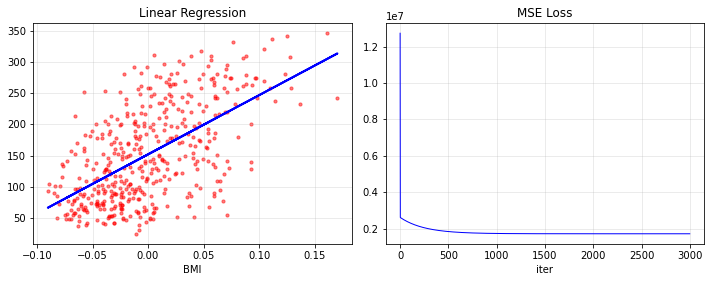

In [13]:
with torch.no_grad():
    y_pred = model(x_t).numpy().flatten()
x_arr = x_t.numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(x_arr, y_t.numpy().flatten(), c='r', s=10, alpha=0.5)
axes[0].plot(x_arr, y_pred, 'b-', lw=2)
axes[0].set_title('Linear Regression'); axes[0].set_xlabel('BMI'); axes[0].grid(alpha=0.3)

axes[1].plot(loss_hist, 'b-', lw=1)
axes[1].set_title('MSE Loss'); axes[1].set_xlabel('iter'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
# 2. Logistic Regression (Binary)

$$\hat{y} = \sigma(\mathbf{Xw}), \qquad J = -\sum \bigl[ y \log \hat{y} + (1-y) \log(1-\hat{y}) \bigr]$$

### 데이터 로드

In [16]:
iris = datasets.load_iris()
mask = iris.target < 2
X_raw = iris.data[mask, :2]
y_np  = iris.target[mask].astype(np.float32)

X_t = torch.tensor(X_raw, dtype=torch.float32)                  # (100, 2)
y_t = torch.tensor(y_np,  dtype=torch.float32).view(-1, 1)      # (100, 1)

print(f'X_t: {X_t.shape}, classes: {np.unique(y_np)}')

X_t: torch.Size([100, 2]), classes: [0. 1.]


### 모델 정의

In [18]:
class BinaryClassifier(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)

    def forward(self, x):
        z = self.linear(x)        # logit — sigmoid은 BCEWithLogitsLoss 내부에서 처리
        return z

torch.manual_seed(42)
model = BinaryClassifier(in_features=2)

### 학습

In [20]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss(reduction='sum')   # sigmoid + BCE 내장
loss_hist = train(model, X_t, y_t, optimizer, loss_fn, n_iter=200)

with torch.no_grad():
    pred = (torch.sigmoid(model(X_t)) >= 0.5).float()
    acc = (pred == y_t).float().mean().item()
print(f'\nfinal loss: {loss_hist[-1]:.4f}, accuracy: {acc:.1%}')


final loss: 4.8822, accuracy: 99.0%


### 시각화

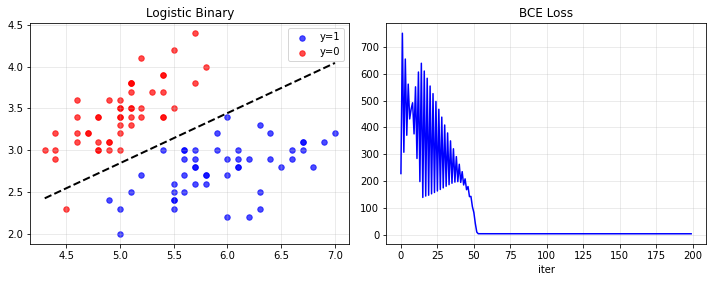

In [22]:
w = model.linear.weight.detach().numpy().flatten()
b = model.linear.bias.item()
pos, neg = y_np == 1, y_np == 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_raw[pos, 0], X_raw[pos, 1], c='b', s=30, label='y=1', alpha=0.7)
axes[0].scatter(X_raw[neg, 0], X_raw[neg, 1], c='r', s=30, label='y=0', alpha=0.7)
x1 = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), 100)
x2 = -(b + w[0] * x1) / w[1]         # 결정 경계: w[0]*x1 + w[1]*x2 + b = 0
axes[0].plot(x1, x2, 'k--', lw=2)
axes[0].set_title('Logistic Binary'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(loss_hist, 'b-', lw=1.5)
axes[1].set_title('BCE Loss'); axes[1].set_xlabel('iter'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
# 3. Logistic Regression (Multi-class)

$$o_k = \text{softmax}(z_k), \qquad J = -\sum_n \log o_{n,y_n}$$

### 데이터 로드

In [25]:
iris = datasets.load_iris()
X_t = torch.tensor(iris.data,   dtype=torch.float32)   # (150, 4)
y_t = torch.tensor(iris.target, dtype=torch.long)      # (150,) — class index

print(f'X_t: {X_t.shape}, classes: {np.unique(iris.target)}')

X_t: torch.Size([150, 4]), classes: [0 1 2]


### 모델 정의

In [27]:
class MultiClassifier(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        logits = self.linear(x)      # logits — log_softmax은 CrossEntropyLoss 내부에서 처리
        return logits

torch.manual_seed(42)
model = MultiClassifier(in_features=4, num_classes=3)

### 학습

In [29]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(reduction='sum')   # log_softmax + NLL 내장
loss_hist = train(model, X_t, y_t, optimizer, loss_fn, n_iter=300)

with torch.no_grad():
    logits = model(X_t)
    pred = logits.argmax(dim=1)
    acc = (pred == y_t).float().mean().item()
print(f'\nfinal loss: {loss_hist[-1]:.4f}, accuracy: {acc:.1%}')


final loss: 23.4236, accuracy: 97.3%


### 시각화

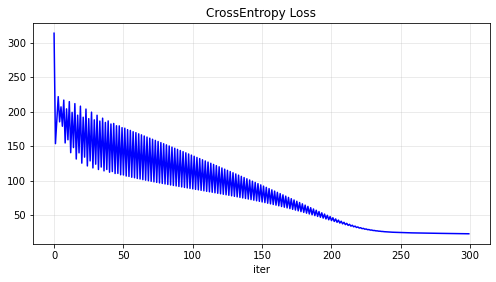

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_hist, 'b-', lw=1.5)
ax.set_title('CrossEntropy Loss'); ax.set_xlabel('iter'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 4. 요약

| | Practice 06 (numpy) | Practice 09 (pytorch) |
|---|---|---|
| **Model** | 행렬 연산 직접 작성 | `nn.Module` 클래스 + `nn.Linear` |
| **Loss** | 수식 직접 구현 | `nn.MSELoss`, `nn.BCEWithLogitsLoss`, `nn.CrossEntropyLoss` |
| **Gradient** | 수식 유도 | `loss.backward()` |
| **Update** | `w -= alpha * dJ` | `optimizer.step()` |
| **학습 루프** | 매번 직접 작성 | `train(model, X, y, optimizer, loss_fn, n_iter)` — **한 줄 재사용** |

모델 정의와 학습 루프가 분리되어, **모델 클래스만 바꿔 끼우면** 동일한 `train()` 함수로 다양한 선형 모델을 학습할 수 있습니다. Practice 07에서 본 MLP 확장도 이 구조에서 그대로 이어집니다.